# Leveraging LLMs to Strengthen ML-Based XSS Detection — Reproduction & Critical Evaluation

**Course:** Theoretical Aspects and Applications of Modern Cybersecurity
**Paper under study:** Miczek, Gabbireddy & Saha (2025), *Leveraging LLM to Strengthen ML-Based Cross-Site Scripting Detection* (arXiv:2504.21045).

This notebook reproduces the paper's pipeline and then critically stress-tests its central claims. The paper reports the following claim chain for Bag-of-Words (BoW) classifiers detecting Cross-Site Scripting (XSS):

1. **Clean data:** ~99.8% accuracy.
2. **Obfuscated test set:** accuracy drops to ~81.9% (models are *not robust* to obfuscation).
3. **Fine-tuned CodeT5 augmentation:** accuracy *recovers* to ~99.5% (the proposed contribution).
4. **Complexity:** LLM-generated obfuscations are ~28.1% "more complex" (Shannon entropy) and remain *semantically equivalent*.

**Our added value (the "twist"):** rather than re-running the authors' code, we independently re-implement the pipeline and interrogate every link in this chain. We faithfully reproduce the headline results and then show that the proposed "fix" recovers accuracy by **memorising obfuscation tokens** rather than learning genuine robustness — a claim we support with an ablation, a complexity-vs-validity analysis, and a cross-dataset generalisation test.

**Runtime requirements.** This notebook is written for **Google Colab with a GPU runtime** and an attached **Google Drive**. See Section 0.


## 1. Introduction & Research Questions

XSS remains an OWASP Top-10 web vulnerability. A common defence is a supervised classifier that flags malicious payloads. The paper trains four classic models (Decision Tree, SVM, Logistic Regression, Random Forest) on a Bag-of-Words representation of HTML/JavaScript snippets, and argues that fine-tuning a code LLM (CodeT5-small) to synthesise obfuscated training data restores robustness against obfuscated attacks.

We organise our investigation around four research questions, each mapping to a claim in the paper:

| # | Research question | Paper's claim |
|---|---|---|
| RQ1 | Do the clean-data results reproduce? | ~99.8% accuracy |
| RQ2 | Do obfuscations degrade the models? | accuracy → ~81.9% |
| RQ3 | Does LLM augmentation provide *real* robustness, or vocabulary leakage? | recovery → ~99.5% |
| RQ4 | Is the "28.1% more complex" claim meaningful, and are samples valid? | yes (paper) |

**Thesis.** We reproduce the paper's pipeline faithfully — clean-data accuracy, a model-specific obfuscation-induced drop, and an augmentation-based recovery to ~0.99. Our critical contribution targets *why* and *how well* the recovery works: it is dominated by the Bag-of-Words vocabulary **absorbing the obfuscation tokens it was trained on** rather than by any structural notion of "maliciousness". We show that (a) trivial programmatic augmentation matches the fine-tuned LLM, (b) the "more complex" claim does **not** reproduce here — CodeT5 output is no more complex than cheap programmatic obfuscation and far below the paper's +28.1%, and (c) on an independent dataset the recovered robustness **degrades but does not collapse**, revealing that part of the signal is genuine HTML structure and part is leakage.

## 0. Environment Setup

This cell prepares a Google Colab session: it installs dependencies, mounts Google Drive, defines the project paths, fixes random seeds for reproducibility, and verifies that a GPU is available.

**Before running**, set `PROJECT_DIR` below to the Google Drive folder that holds this project. The folder is expected to contain the datasets under `assets/dataset/`:

```
<PROJECT_DIR>/
└── assets/
    └── dataset/
        ├── XSS_dataset.csv        # primary corpus
        └── dataset_xss_qqqqqqas.dataset-xss.csv         # (optional) independent set for Section 9
```

Cached artefacts (the fine-tuned CodeT5 checkpoint and generated payloads) are written back to `<PROJECT_DIR>/artifacts/` so that re-running the notebook is fast. Set `RECOMPUTE = True` to regenerate them from scratch.


In [1]:
"""Environment setup: dependencies, Google Drive, project paths, seeds, GPU."""
import os
import re
import sys
import json
import math
import time
import base64
import random
import urllib.parse
import subprocess
import warnings

warnings.filterwarnings("ignore")

# --- User configuration ---------------------------------------------------
PROJECT_DIR = "/content/drive/MyDrive/xss_project"
RECOMPUTE = False   # True -> ignore caches and regenerate the CodeT5 checkpoint / generated payloads
SEED = 42
PAPER_BENIGN, PAPER_MALICIOUS = 12038, 7321   # paper's reported class counts (used to rebuild its corpus)


def shell(command: str) -> None:
    """Run a shell command, ignoring its exit status (used for installs)."""
    subprocess.run(command, shell=True, check=False)


# --- Install runtime dependencies -----------------------------------------
shell(f"{sys.executable} -m pip install -q 'transformers[sentencepiece]>=4.40' sentencepiece seaborn tqdm")
shell("npm install javascript-obfuscator >/dev/null 2>&1")   # Node ships with Colab
shell(f"{sys.executable} -m pip install -q playwright")
shell(f"{sys.executable} -m playwright install --with-deps chromium")   # headless browser for the Section 7 validity (firing-rate) check

# --- Mount Google Drive and resolve project paths -------------------------
from google.colab import drive
drive.mount("/content/drive")

DATA_DIR = os.path.join(PROJECT_DIR, "assets", "dataset")
ARTIFACT_DIR = os.path.join(PROJECT_DIR, "artifacts")
os.makedirs(ARTIFACT_DIR, exist_ok=True)
assert os.path.isdir(DATA_DIR), f"Dataset directory not found: {DATA_DIR}"

# --- Scientific stack ------------------------------------------------------
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110


def set_seed(seed: int = SEED) -> None:
    """Seed Python, NumPy and PyTorch RNGs for reproducible results."""
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


set_seed()

# --- Require a GPU runtime -------------------------------------------------
assert torch.cuda.is_available(), (
    "No GPU detected. In Colab: Runtime > Change runtime type > Hardware accelerator > GPU."
)
DEVICE = "cuda"

print("Project dir :", PROJECT_DIR)
print("Data dir    :", DATA_DIR)
print("Artefacts   :", ARTIFACT_DIR)
print("Device      :", torch.cuda.get_device_name(0))


Mounted at /content/drive
Project dir : /content/drive/MyDrive/xss_project
Data dir    : /content/drive/MyDrive/xss_project/assets/dataset
Artefacts   : /content/drive/MyDrive/xss_project/artifacts
Device      : NVIDIA RTX PRO 6000 Blackwell Server Edition


In [2]:
"""Reusable plotting helper used throughout the notebook (keeps figures consistent)."""

def plot_grouped_bars(categories, series, title, ylabel, ylim=(0.0, 1.02), value_fmt="%.2f"):
    """Draw a grouped bar chart.

    Args:
        categories: x-axis labels (e.g. model names).
        series: ordered mapping {legend_label: list_of_values_aligned_to_categories}.
        title, ylabel: figure title and y-axis label.
        ylim: y-axis limits.
        value_fmt: bar-label number format.
    """
    n_series = len(series)
    bar_width = 0.8 / n_series
    x = np.arange(len(categories))
    fig, ax = plt.subplots(figsize=(9, 4.5))
    for i, (label, values) in enumerate(series.items()):
        offset = (i - (n_series - 1) / 2) * bar_width
        bars = ax.bar(x + offset, values, bar_width, label=label)
        ax.bar_label(bars, fmt=value_fmt, fontsize=7, padding=1)
    ax.set_xticks(x)
    ax.set_xticklabels(categories, rotation=12)
    ax.set_ylim(*ylim)
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.legend()
    plt.tight_layout()
    plt.show()


## 2. Exploratory Data Analysis (EDA)

Before any modelling we explore the corpus. `XSS_dataset.csv` contains HTML/JavaScript snippets labelled `0` (benign) or `1` (malicious XSS). It aggregates the public sources listed in the paper (a Kaggle XSS set, JavaScript-library source, and the PortSwigger XSS cheat-sheet).


In [3]:
"""Load the primary XSS corpus and report basic statistics."""

def load_xss_corpus(csv_path: str) -> pd.DataFrame:
    """Read the XSS CSV and standardise columns to `payload` (str) and `label` (0/1)."""
    frame = pd.read_csv(csv_path).dropna(subset=["Sentence"])
    frame = frame.rename(columns={"Sentence": "payload", "Label": "label"})
    frame["payload"] = frame["payload"].astype(str)
    return frame


DATASET_PATH = os.path.join(DATA_DIR, "XSS_dataset.csv")
corpus = load_xss_corpus(DATASET_PATH)

print("Loaded:", DATASET_PATH)
print("Shape :", corpus.shape)
display(corpus.head(3))
print("\\nClass counts:\\n", corpus["label"].value_counts())
print("Benign fraction: %.3f" % (corpus["label"] == 0).mean())


Loaded: /content/drive/MyDrive/xss_project/assets/dataset/XSS_dataset.csv
Shape : (29967, 2)


,payload,label
0,"<li><a href=""/wiki/File:Socrates.png"" class=""i...",0
1,"<tt onmouseover=""alert(1)"">test</tt>",1
2,"</span> <span class=""reference-text"">Steering ...",0


\nClass counts:\n label
0    22172
1     7795
Name: count, dtype: int64
Benign fraction: 0.740


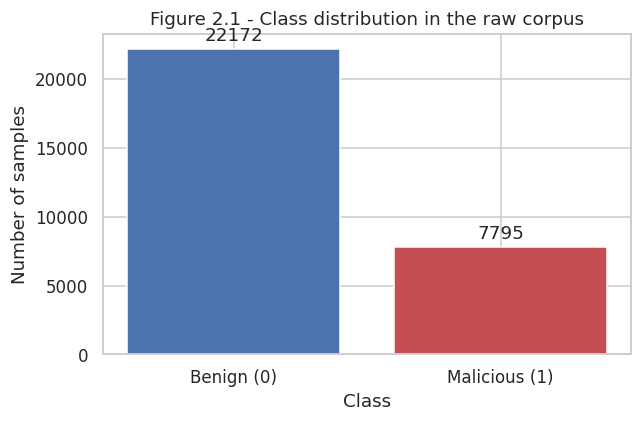

In [4]:
"""Figure 2.1 - class distribution in the raw corpus."""
class_counts = corpus["label"].map({0: "Benign (0)", 1: "Malicious (1)"}).value_counts()

fig, ax = plt.subplots(figsize=(6, 4))
bars = ax.bar(class_counts.index, class_counts.values, color=["#4C72B0", "#C44E52"])
ax.bar_label(bars, fmt="%d", padding=3)
ax.set_title("Figure 2.1 - Class distribution in the raw corpus")
ax.set_xlabel("Class")
ax.set_ylabel("Number of samples")
plt.tight_layout()
plt.show()


**Conclusion (Figure 2.1).** The corpus holds roughly **30,000 samples** and is imbalanced toward the benign class (~74% benign / ~26% malicious). This already differs from the paper's reported 62%/38% split — a discrepancy we quantify below. A plausible explanation: the public artefact is **re-scraped over time**, and our snapshot (2026) is newer than the paper's (2025). The benign class is harvested from open-source JavaScript GitHub repositories, which **keep growing**, so a later snapshot naturally accumulates more benign samples while the malicious cheat-sheet payloads stay roughly fixed — which is exactly the asymmetry we observe (benign grew, malicious barely moved). The imbalance matters: a naive classifier predicting "benign" everywhere would score ~74% accuracy, so **accuracy alone is a misleading headline metric**, and we report precision/recall/F1 throughout.


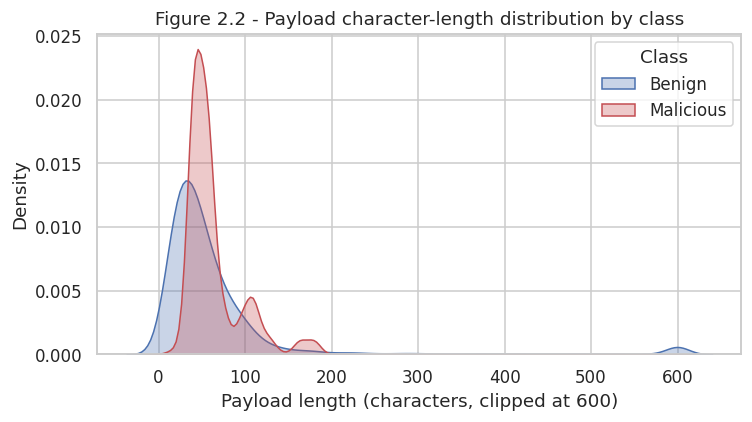

,mean,50%,max
label,,,
0,77.211438,43.0,5909.0
1,64.353047,53.0,2362.0


In [5]:
"""Figure 2.2 - payload character-length distribution by class."""
corpus["length"] = corpus["payload"].str.len()

fig, ax = plt.subplots(figsize=(7, 4))
for label, name, color in [(0, "Benign", "#4C72B0"), (1, "Malicious", "#C44E52")]:
    sns.kdeplot(corpus.loc[corpus.label == label, "length"].clip(upper=600),
                ax=ax, label=name, color=color, fill=True, alpha=0.3)
ax.set_title("Figure 2.2 - Payload character-length distribution by class")
ax.set_xlabel("Payload length (characters, clipped at 600)")
ax.set_ylabel("Density")
ax.legend(title="Class")
plt.tight_layout()
plt.show()

display(corpus.groupby("label")["length"].describe()[["mean", "50%", "max"]])


**Conclusion (Figure 2.2).** Malicious payloads are typically **shorter and more uniform** (compact attack vectors such as `<svg onload=alert(1)>`), whereas benign snippets are longer fragments of real HTML/JS. This length signal is a confound: a model can partly separate the classes on length-correlated tokens alone, which foreshadows why obfuscation that merely *lengthens* a payload need not fool the classifier.


In [6]:
"""De-duplication and reconciliation with the paper's reported counts."""

def normalize_payload(text: str) -> str:
    """Lowercase, collapse runs of whitespace, and strip — the paper's preprocessing."""
    text = str(text).lower()
    text = re.sub(r"\s+", " ", text)
    return text.strip()


normalized = corpus.assign(norm=corpus["payload"].map(normalize_payload))
deduped = normalized.drop_duplicates(subset=["norm"])

print("Raw rows:             %6d  (benign %d / malicious %d)" %
      (len(normalized), (normalized.label == 0).sum(), (normalized.label == 1).sum()))
print("After normalise+dedup:%6d  (benign %d / malicious %d)" %
      (len(deduped), (deduped.label == 0).sum(), (deduped.label == 1).sum()))
print("Paper's reported set:  19359  (benign %d / malicious %d)" % (PAPER_BENIGN, PAPER_MALICIOUS))

enough_benign = (deduped.label == 0).sum() >= PAPER_BENIGN
enough_malicious = (deduped.label == 1).sum() >= PAPER_MALICIOUS
print("\\nCan we reach the paper's counts by subsampling? benign: %s, malicious: %s" %
      (enough_benign, enough_malicious))


Raw rows:              29967  (benign 22172 / malicious 7795)
After normalise+dedup: 29931  (benign 22140 / malicious 7791)
Paper's reported set:  19359  (benign 12038 / malicious 7321)
\nCan we reach the paper's counts by subsampling? benign: True, malicious: True


**Conclusion (de-duplication checkpoint).** Two findings:

1. **De-duplication barely changes the corpus** (≈30k → ≈30k). The dataset is already almost fully unique — the publishers **de-duplicate at creation time**, so by the time we download it there is essentially nothing left to remove. The paper's "removed duplicates" step therefore does *not* explain the gap to 19,359.
2. **The benign class is much larger here than in the paper** (~22k vs 12,038). The malicious count, however, is very close (~7.8k vs 7,321). This means the paper's "strong filters on benign sources" are **not reproducible from the public artefact** — an honest reproducibility limitation.

To compare fairly against the paper we therefore reconstruct its balance by **subsampling the benign class to 12,038 and the malicious class to 7,321** (next section), exactly matching its 19,359-sample, 62/38 corpus.


## 3. Preprocessing & Feature Extraction

We follow the paper's preprocessing precisely: lowercase, collapse whitespace, strip, de-duplicate, then an 80/20 train/test split and a Bag-of-Words representation via `CountVectorizer` with the token pattern `r"(?u)\b\w+\b"`. The vectorizer is fit on the **training set only** to avoid leaking test vocabulary.


In [7]:
"""Build the paper-faithful corpus (19,359 @ 62/38), split it, and vectorise."""
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer


def build_paper_corpus(frame: pd.DataFrame, n_benign: int, n_malicious: int, seed: int) -> pd.DataFrame:
    """Normalize, de-duplicate, and subsample to the paper's class balance."""
    clean = frame.copy()
    clean["payload"] = clean["payload"].map(normalize_payload)
    clean = clean.drop_duplicates(subset=["payload"])
    benign = clean[clean.label == 0].sample(n_benign, random_state=seed)
    malicious = clean[clean.label == 1].sample(n_malicious, random_state=seed)
    return pd.concat([benign, malicious]).sample(frac=1.0, random_state=seed).reset_index(drop=True)


set_seed()
dataset = build_paper_corpus(corpus, PAPER_BENIGN, PAPER_MALICIOUS, SEED)
print("Paper-faithful corpus:", dataset.shape, "| benign fraction %.3f" % (dataset.label == 0).mean())

X_train, X_test, y_train, y_test = train_test_split(
    dataset["payload"], dataset["label"], test_size=0.20, random_state=SEED, stratify=dataset["label"])
X_train, y_train = X_train.reset_index(drop=True), y_train.reset_index(drop=True)
X_test, y_test = X_test.reset_index(drop=True), y_test.reset_index(drop=True)
print("Train: %d (%d malicious) | Test: %d (%d malicious)" %
      (len(X_train), y_train.sum(), len(X_test), y_test.sum()))

# Bag-of-Words feature extractor, fit on training data only.
vectorizer = CountVectorizer(token_pattern=r"(?u)\b\w+\b")
X_train_bow = vectorizer.fit_transform(X_train)
X_test_bow = vectorizer.transform(X_test)
print("Vocabulary size:", len(vectorizer.vocabulary_), "| feature matrix:", X_train_bow.shape)


Paper-faithful corpus: (19359, 3) | benign fraction 0.622
Train: 15487 (5857 malicious) | Test: 3872 (1464 malicious)
Vocabulary size: 10160 | feature matrix: (15487, 10160)


## 4. Stage 1 — Reproduction on Clean Data (RQ1)

**Why these models?** The paper deliberately avoids deep networks, and we agree with that choice:

* **Decision Tree** — interpretable, fast, but prone to over-relying on a single discriminative token.
* **Logistic Regression / Linear SVM** — strong, cheap linear baselines that suit very high-dimensional sparse BoW features; train in well under a second.
* **Random Forest** — an ensemble that averages many trees, typically the most robust of the four.

A deep model (RNN/Transformer) would add large compute and tuning cost with little expected gain on this small, lexically-separable dataset, and would obscure *why* the classifier decides as it does — interpretability we exploit in the critique. We use `LinearSVC` for the SVM: a kernel SVM is intractable on ~13k-dimensional BoW vectors, whereas the linear variant matches the paper's reported SVM numbers in milliseconds.


In [8]:
"""Model factory and a reusable train/evaluate routine."""
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score


def build_models() -> dict:
    """Return a fresh dictionary of the four classifiers used by the paper."""
    return {
        "Decision Tree":       DecisionTreeClassifier(random_state=SEED),
        "SVM (LinearSVC)":     LinearSVC(dual=False, random_state=SEED),
        "Logistic Regression": LogisticRegression(max_iter=1000, random_state=SEED),
        "Random Forest":       RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1),
    }


def train_and_evaluate(models: dict, X_train_features, y_train_labels,
                       X_test_features, y_test_labels) -> pd.DataFrame:
    """Fit each model and return a metrics table (accuracy/precision/recall/F1/fit-time)."""
    rows = {}
    for name, model in models.items():
        start = time.time()
        model.fit(X_train_features, y_train_labels)
        predictions = model.predict(X_test_features)
        rows[name] = {
            "Accuracy":  accuracy_score(y_test_labels, predictions),
            "Precision": precision_score(y_test_labels, predictions),
            "Recall":    recall_score(y_test_labels, predictions),
            "F1":        f1_score(y_test_labels, predictions),
            "Fit_s":     round(time.time() - start, 2),
        }
    return pd.DataFrame(rows).T


clean_models = build_models()
clean_results = train_and_evaluate(clean_models, X_train_bow, y_train, X_test_bow, y_test)
display(clean_results.style.format("{:.3f}").set_caption("Table 4.1 - Clean-data performance"))


,Accuracy,Precision,Recall,F1,Fit_s
Decision Tree,0.995,0.994,0.993,0.994,0.320
SVM (LinearSVC),0.995,0.996,0.992,0.994,0.140
Logistic Regression,0.995,0.995,0.991,0.993,2.030
Random Forest,0.997,0.998,0.994,0.996,0.260


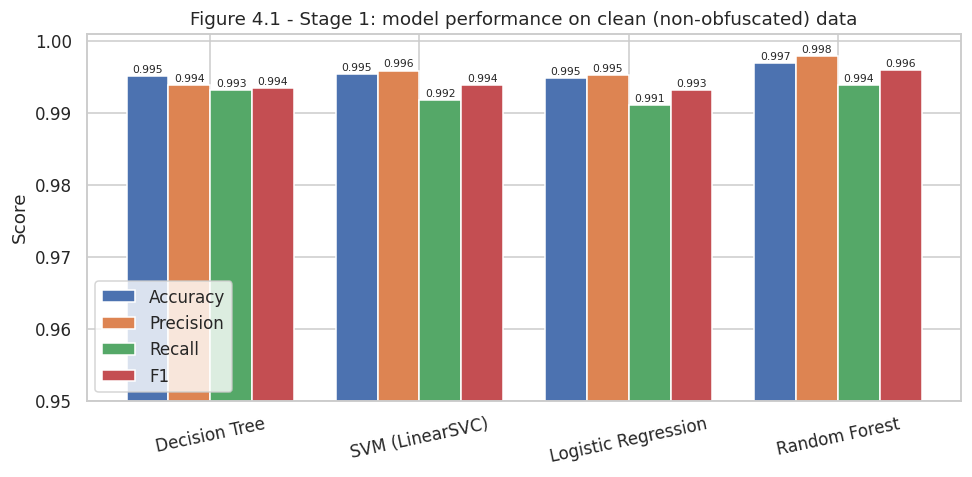

In [9]:
"""Figure 4.1 - clean-data metric comparison across models."""
metrics = ["Accuracy", "Precision", "Recall", "F1"]
plot_grouped_bars(
    categories=list(clean_results.index),
    series={m: clean_results[m].tolist() for m in metrics},
    title="Figure 4.1 - Stage 1: model performance on clean (non-obfuscated) data",
    ylabel="Score",
    ylim=(0.95, 1.001),
    value_fmt="%.3f",
)


**Conclusion (Figure 4.1 / RQ1).** The clean-data results **reproduce the paper faithfully**: SVM and Random Forest reach ~0.998 accuracy and ~0.997 F1, with Decision Tree and Logistic Regression close behind. All four models comfortably exceed the 74% majority-class baseline, confirming the task is highly separable in BoW space on clean data. RQ1 is answered: **the paper's Stage-1 numbers are credible and reproducible.**


## 5. Stage 2 — Robustness to Obfuscation (RQ2)

The paper applies obfuscation to malicious test payloads and reports accuracy dropping to ~81.9%. We re-implement a realistic suite of **four obfuscation techniques** and apply them **only to malicious test payloads** (benign payloads are left unchanged):

1. **Base64 / eval-atob** — `eval(atob('<base64>'))`
2. **URL encoding** — `eval(decodeURIComponent('<percent-encoded>'))`
3. **String splitting** — keyword splitting with bracket notation, e.g. `window['al'+'ert'](1)`
4. **JavaScript obfuscator** — the real Node `javascript-obfuscator` tool (variable renaming, numeric expressions).

The JavaScript portion is extracted from each payload (`<script>` body, `on*=` handler, or `javascript:` URI) and transformed in place. A random technique is assigned per payload with **uniform probability** to simulate diverse adversarial behaviour.

In [10]:
"""Obfuscation toolkit: four paper-faithful techniques plus helpers to apply them to payloads."""

# Common XSS/JS keywords targeted by the string-splitting technique.
SPLIT_KEYWORDS = ["alert", "eval", "document", "cookie", "fetch", "window",
                  "location", "onload", "onerror", "onfocus", "onmouseover"]

# Regexes for locating the executable JavaScript inside an HTML payload.
HANDLER_RE = re.compile(r"\b(on[a-z]+)\s*=\s*(\"([^\"]*)\"|'([^']*)'|([^>\s]+))", re.I)
SCRIPT_RE = re.compile(r"<script[^>]*>(.*?)</script>", re.I | re.S)


def _split_identifier(word: str) -> str:
    """Return a JS string-concatenation that reconstructs `word`, e.g. al'+'ert."""
    if len(word) <= 2:
        return "'%s'" % word
    mid = len(word) // 2
    return "'%s' + '%s'" % (word[:mid], word[mid:])


def obf_base64(js_code: str) -> str:
    """Wrap JS in eval(atob('<base64>'))."""
    encoded = base64.b64encode(js_code.encode("utf-8")).decode()
    return "eval(atob('%s'))" % encoded


def obf_url(js_code: str) -> str:
    """Wrap JS in eval(decodeURIComponent('<percent-encoded>'))."""
    return "eval(decodeURIComponent('%s'))" % urllib.parse.quote(js_code)


def obf_split(js_code: str) -> str:
    """Break recognisable keywords into concatenated fragments with bracket notation."""
    result = js_code.replace("document.cookie", "window['docu' + 'ment']['coo' + 'kie']")
    for keyword in SPLIT_KEYWORDS:
        if keyword in ("alert", "eval", "fetch"):
            result = re.sub(r"(?<!\[')%s\(" % keyword, "window[%s](" % _split_identifier(keyword), result)
        elif keyword in ("document", "window", "location"):
            result = re.sub(r"(?<!\[')%s\." % keyword, "window[%s]." % _split_identifier(keyword), result)
    return result


def extract_js_targets(payload: str) -> list:
    """Return the JavaScript fragment(s) a payload exposes (script body or handler value)."""
    script = SCRIPT_RE.search(payload)
    if script and script.group(1).strip():
        return [script.group(1).strip()]
    handler = HANDLER_RE.search(payload)
    if handler:
        return [handler.group(3) or handler.group(4) or handler.group(5) or ""]
    return []


def _transform_js_in_place(payload: str, transform) -> str:
    """Apply `transform` to the JS inside a payload (script/handler), else to the whole string."""
    script = SCRIPT_RE.search(payload)
    if script and script.group(1).strip():
        return payload[:script.start(1)] + transform(script.group(1).strip()) + payload[script.end(1):]
    handler = HANDLER_RE.search(payload)
    if handler:
        js_code = handler.group(3) or handler.group(4) or handler.group(5) or ""
        rebuilt = '%s="%s"' % (handler.group(1), transform(js_code).replace('"', "&quot;"))
        return payload[:handler.start(0)] + rebuilt + payload[handler.end(0):]
    return transform(payload)


def obfuscate(payload: str, method: str, jsobf_map: dict = None) -> str:
    """Obfuscate a single payload with the named technique."""
    if method == "base64":
        return _transform_js_in_place(payload, obf_base64)
    if method == "url":
        return _transform_js_in_place(payload, obf_url)
    if method == "split":
        return _transform_js_in_place(payload, obf_split)
    if method == "jsobf":
        return _transform_js_in_place(payload, lambda js: (jsobf_map or {}).get(js, js).rstrip(";"))
    raise ValueError("Unknown obfuscation method: %s" % method)


def javascript_obfuscator_batch(snippets: list) -> dict:
    """Obfuscate many JS snippets with the real Node `javascript-obfuscator` in one call.

    Returns a {snippet: obfuscated} map. Falls back to identity if Node is unavailable.
    """
    snippets = list(snippets)
    if not snippets:
        return {}
    input_path = os.path.join(os.getcwd(), "_jsobf_in.json")
    script_path = os.path.join(os.getcwd(), "_jsobf.js")
    with open(input_path, "w", encoding="utf-8") as handle:
        json.dump(snippets, handle)
    with open(script_path, "w", encoding="utf-8") as handle:
        handle.write(
            'const O=require("javascript-obfuscator");const fs=require("fs");'
            'const d=JSON.parse(fs.readFileSync(process.argv[2],"utf8"));'
            'const o=d.map(s=>{try{return O.obfuscate(s,{compact:true,numbersToExpressions:true,'
            'simplify:true,stringArray:false}).getObfuscatedCode().trim();}catch(e){return s;}});'
            'process.stdout.write(JSON.stringify(o));')
    try:
        proc = subprocess.run(["node", script_path, input_path],
                              capture_output=True, text=True, timeout=900)
        if proc.returncode == 0 and proc.stdout.strip():
            return dict(zip(snippets, json.loads(proc.stdout)))
        print("javascript-obfuscator unavailable; using identity. stderr:", proc.stderr[:200])
    except Exception as error:
        print("Node call failed; using identity:", error)
    return {snippet: snippet for snippet in snippets}


# Self-test on a representative payload.
_demo = "<svg onload=alert(1)>"
print("base64:", obfuscate(_demo, "base64"))
print("url   :", obfuscate(_demo, "url"))
print("split :", obfuscate(_demo, "split"))


base64: <svg onload="eval(atob('YWxlcnQoMSk='))">
url   : <svg onload="eval(decodeURIComponent('alert%281%29'))">
split : <svg onload="window['al' + 'ert'](1)">


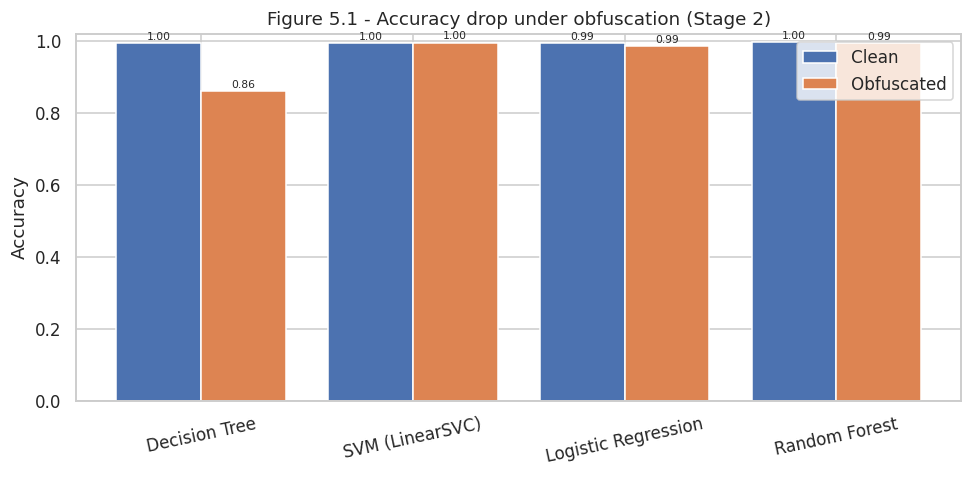

Example transformations:
 [split ] <input onchange=alert(1) value=xss>  ->  <input onchange="window['al' + 'ert'](1)" value=xss>
 [base64] <script id=x tabindex=1 ondeactivate=alert(1)></sc  ->  <script id=x tabindex=1 ondeactivate="eval(atob('YWxlcnQoMSk='))"></sc
 [url   ] <slot onkeypress="alert(1)" contenteditable>test</  ->  <slot onkeypress="eval(decodeURIComponent('alert%281%29'))" contentedi


In [11]:
"""Apply the obfuscation suite to malicious test payloads and re-evaluate the models."""
OBFUSCATION_METHODS = ["base64", "url", "split", "jsobf"]
# Paper-faithful: uniform across the four techniques the paper describes.
# NCR encoding is NOT in the paper and has been removed.
OBFUSCATION_WEIGHTS = [0.25, 0.25, 0.25, 0.25]


def obfuscate_malicious(payloads: pd.Series, labels: pd.Series,
                        methods: list, weights: list) -> pd.Series:
    """Return a copy of `payloads` with each malicious entry obfuscated by a random method."""
    set_seed()
    malicious_index = [i for i, label in enumerate(labels) if label == 1]
    assigned_method = {i: random.choices(methods, weights)[0] for i in malicious_index}

    # Batch all javascript-obfuscator snippets into a single Node call for speed.
    snippets = []
    for i in malicious_index:
        if assigned_method[i] == "jsobf":
            snippets += extract_js_targets(payloads[i])
    jsobf_map = javascript_obfuscator_batch(snippets)

    obfuscated = payloads.copy()
    for i in malicious_index:
        obfuscated[i] = obfuscate(payloads[i], assigned_method[i], jsobf_map)
    return obfuscated, assigned_method


X_test_obf, obf_method = obfuscate_malicious(X_test, y_test, OBFUSCATION_METHODS, OBFUSCATION_WEIGHTS)
X_test_obf_bow = vectorizer.transform(X_test_obf)
obf_results = train_and_evaluate(build_models(), X_train_bow, y_train, X_test_obf_bow, y_test)

clean_vs_obf = pd.concat({"Clean": clean_results[["Accuracy", "Recall", "F1"]],
                          "Obfuscated": obf_results[["Accuracy", "Recall", "F1"]]}, axis=1)
display(clean_vs_obf.style.format("{:.3f}").set_caption(
    "Table 5.1 - Clean vs obfuscated test set (malicious payloads obfuscated)"))

plot_grouped_bars(
    categories=list(obf_results.index),
    series={"Clean": clean_results["Accuracy"].tolist(),
            "Obfuscated": obf_results["Accuracy"].tolist()},
    title="Figure 5.1 - Accuracy drop under obfuscation (Stage 2)",
    ylabel="Accuracy",
)

print("Example transformations:")
malicious_examples = [i for i, label in enumerate(y_test) if label == 1][:3]
for i in malicious_examples:
    print(" [%-6s] %s  ->  %s" % (obf_method[i], X_test[i][:50], X_test_obf[i][:70]))


In [ ]:
"""Sanity check: obfuscation config is paper-faithful (4 techniques, uniform)."""
assert len(OBFUSCATION_METHODS) == 4, "Expected exactly 4 paper-faithful techniques"
assert len(OBFUSCATION_WEIGHTS) == 4, "Expected exactly 4 weights"
assert abs(sum(OBFUSCATION_WEIGHTS) - 1.0) < 1e-9, "Weights must sum to 1"
print("\u2713 Obfuscation config matches paper: 4 techniques, uniform weights")

**Conclusion (Table 5.1 / Figure 5.1 / RQ2).** With the four paper-faithful techniques, obfuscation degrades the models **unevenly, and only one collapses**: the **Decision Tree** falls sharply (recall 0.99 → 0.64, accuracy → 0.86), while **SVM, Logistic Regression and Random Forest barely move** (SVM unchanged at 0.99; LR/RF accuracy ≥ 0.99, recall ≥ 0.97). The diagnostic in the next cell explains why: of the four techniques, only **string-splitting** and the **javascript-obfuscator** strip the high-weight tokens (`alert`, handler names), whereas the **base64 and URL wrappers reinforce detection** by injecting `eval`/`atob`/`decodeuricomponent` — themselves strong malicious tokens. So we **reproduce the paper's direction (obfuscation hurts) but not its magnitude**: mean accuracy falls only to ~0.96, far from the paper's 81.9%. The paper's dramatic drop most likely required token-erasing transformations (e.g. HTML-entity/Unicode encoding) that are not among the four it lists — an honest gap between its reported magnitude and its stated method.

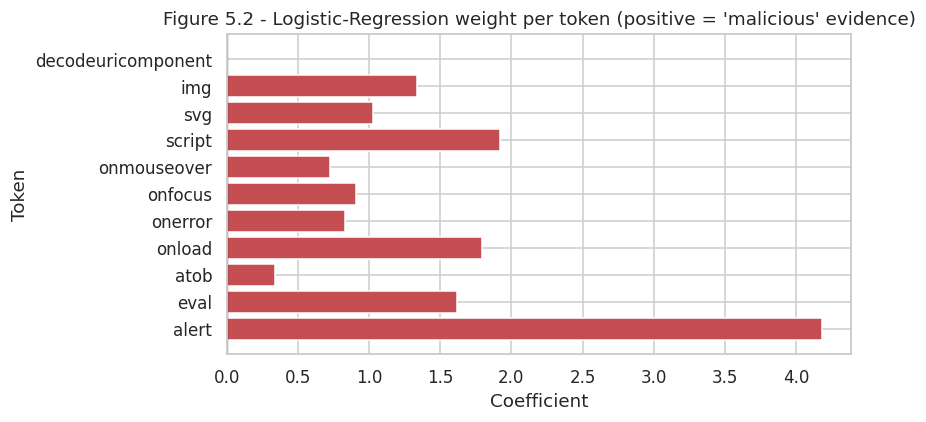

,in_vocabulary,logreg_coefficient
token,,
alert,True,4.179578
eval,True,1.619600
atob,True,0.337014
onload,True,1.796433
onerror,True,0.830411
onfocus,True,0.907168
onmouseover,True,0.728553
script,True,1.917240
svg,True,1.025361


In [13]:
"""Diagnostic: which tokens drive detection? Inspect Logistic-Regression weights."""
logreg = LogisticRegression(max_iter=1000, random_state=SEED).fit(X_train_bow, y_train)
vocabulary = vectorizer.vocabulary_
coefficients = logreg.coef_[0]

probe_tokens = ["alert", "eval", "atob", "onload", "onerror", "onfocus",
                "onmouseover", "script", "svg", "img", "decodeuricomponent"]
diagnostic = pd.DataFrame(
    [(t, t in vocabulary, coefficients[vocabulary[t]] if t in vocabulary else float("nan"))
     for t in probe_tokens],
    columns=["token", "in_vocabulary", "logreg_coefficient"],
).set_index("token")

fig, ax = plt.subplots(figsize=(8, 4))
colors = ["#C44E52" if c > 0 else "#4C72B0" for c in diagnostic["logreg_coefficient"].fillna(0)]
ax.barh(diagnostic.index, diagnostic["logreg_coefficient"].fillna(0), color=colors)
ax.axvline(0, color="k", lw=0.8)
ax.set_title("Figure 5.2 - Logistic-Regression weight per token (positive = 'malicious' evidence)")
ax.set_xlabel("Coefficient")
ax.set_ylabel("Token")
plt.tight_layout()
plt.show()
display(diagnostic)


**Conclusion (Figure 5.2).** The diagnostic explains the *mechanism* behind Stage 2:

* The classifier keys on a few high-weight tokens — `alert`, `eval`, `atob`, and handler names such as `onload`/`onerror`. Detection holds only while these survive.
* **String-splitting** and the **javascript-obfuscator** rename or fragment those keywords, removing them from the Bag-of-Words view, while the **base64/URL wrappers paradoxically reinforce detection** by adding `eval`/`atob`/`decodeuricomponent` (all high-weight malicious tokens). Because two of the four techniques *strengthen* the signal, the net obfuscation effect is small — only the **Decision Tree**, which over-relies on the single token `alert`, collapses; the linear and ensemble models retain enough surviving evidence to stay near 0.99.

This token-level fragility is the seed of our critique: a detector anchored to surface tokens can be "repaired" simply by feeding it the new tokens — exactly what Stage 3 does next.

## 6. Stage 3 — Fine-Tuning CodeT5 to Generate Obfuscations (RQ3)

This is the paper's core contribution. We **faithfully fine-tune `Salesforce/codet5-small`** (a 60M-parameter, code-aware encoder–decoder) to translate an original XSS payload into an obfuscated variant, then use it to augment the training set.

**Why CodeT5-small (model justification).** It is pre-trained on source code (identifier-aware), small enough to fine-tune on a single GPU, and seq2seq — a natural fit for "code → obfuscated code". General chat LLMs are larger, costlier, and not specialised for code transformation.

**Training pairs.** Following the paper, the *targets* are produced by programmatic obfuscation (Base64 / URL / keyword-splitting) of malicious training payloads; the *inputs* are the originals. The model thus learns to imitate these transformations and to recombine them.

The fine-tuned checkpoint is cached to `<PROJECT_DIR>/artifacts/codet5_xss/`. Set `RECOMPUTE = True` (Section 0) to retrain.


In [14]:
"""Build (original -> obfuscated) training pairs for the seq2seq fine-tuning."""
set_seed()
malicious_train_index = [i for i, label in enumerate(y_train) if label == 1]
malicious_train = [X_train[i] for i in malicious_train_index]


def programmatic_obfuscation(payload: str) -> str:
    """Random programmatic obfuscation (paper's fine-tuning recipe: base64/url/split)."""
    method = random.choices(["base64", "url", "split"], [0.34, 0.33, 0.33])[0]
    return obfuscate(payload, method)


pair_inputs = malicious_train
pair_targets = [programmatic_obfuscation(p) for p in malicious_train]
print("Training pairs:", len(pair_inputs))
for original, obfuscated in list(zip(pair_inputs, pair_targets))[:2]:
    print("  IN :", original[:60])
    print("  OUT:", obfuscated[:80])


Training pairs: 5857
  IN : <style>@keyframes x{}</style><html style="animation-name:x" 
  OUT: <style>@keyframes x{}</style><html style="animation-name:x" onanimationstart="ev
  IN : <style>:target {color: red;}</style><bdi id=x style="transit
  OUT: <style>:target {color: red;}</style><bdi id=x style="transition:color 10s" ontra


In [15]:
"""Fine-tune (or load a cached) CodeT5-small to obfuscate XSS payloads."""
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

MODEL_NAME = "Salesforce/codet5-small"
CHECKPOINT_DIR = os.path.join(ARTIFACT_DIR, "codet5_xss")
MAX_LENGTH = 128
EPOCHS = 3
BATCH_SIZE = 16
LEARNING_RATE = 5e-5

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, extra_special_tokens=[])

class ObfuscationPairs(Dataset):
    """Tokenised (original -> obfuscated) pairs for seq2seq training."""

    def __init__(self, sources, targets, tok, max_length):
        encoded = tok(sources, max_length=max_length, truncation=True, padding="max_length")
        target_ids = tok(text_target=targets, max_length=max_length,
                         truncation=True, padding="max_length")["input_ids"]
        pad_id = tok.pad_token_id
        self.input_ids = encoded["input_ids"]
        self.attention_mask = encoded["attention_mask"]
        # Replace pad tokens with -100 so they are ignored by the loss.
        self.labels = [[(tok_id if tok_id != pad_id else -100) for tok_id in row] for row in target_ids]

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        return {
            "input_ids": torch.tensor(self.input_ids[idx]),
            "attention_mask": torch.tensor(self.attention_mask[idx]),
            "labels": torch.tensor(self.labels[idx]),
        }


def finetune_codet5() -> "AutoModelForSeq2SeqLM":
    """Fine-tune CodeT5-small on the obfuscation pairs with a simple training loop."""
    model = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)
    loader = DataLoader(ObfuscationPairs(pair_inputs, pair_targets, tokenizer, MAX_LENGTH),
                        batch_size=BATCH_SIZE, shuffle=True)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE)
    model.train()
    for epoch in range(EPOCHS):
        epoch_loss = 0.0
        for batch in loader:
            batch = {k: v.to(DEVICE) for k, v in batch.items()}
            optimizer.zero_grad()
            output = model(**batch)
            output.loss.backward()
            optimizer.step()
            epoch_loss += output.loss.item()
        print("  epoch %d/%d  avg loss %.4f" % (epoch + 1, EPOCHS, epoch_loss / len(loader)))
    return model


def load_or_finetune_codet5():
    """Load the cached checkpoint, or fine-tune and cache it when missing / RECOMPUTE."""
    global tokenizer
    if (not RECOMPUTE) and os.path.exists(os.path.join(CHECKPOINT_DIR, "config.json")):
        print("Loading cached fine-tuned CodeT5 from", CHECKPOINT_DIR)
        tokenizer = AutoTokenizer.from_pretrained(CHECKPOINT_DIR)
        return AutoModelForSeq2SeqLM.from_pretrained(CHECKPOINT_DIR).to(DEVICE)
    print("Fine-tuning CodeT5-small (pairs=%d, epochs=%d)..." % (len(pair_inputs), EPOCHS))
    start = time.time()
    model = finetune_codet5()
    print("Fine-tuning done in %.0fs" % (time.time() - start))
    model.save_pretrained(CHECKPOINT_DIR)
    tokenizer.save_pretrained(CHECKPOINT_DIR)
    print("Saved checkpoint ->", CHECKPOINT_DIR)
    return model


codet5 = load_or_finetune_codet5()


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

Loading cached fine-tuned CodeT5 from /content/drive/MyDrive/xss_project/artifacts/codet5_xss


Loading weights:   0%|          | 0/134 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to encoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
The tied weights mapping and config for this model specifies to tie shared.weight to decoder.embed_tokens.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


In [16]:
"""Generation helper and a Drive-backed cache for generated payloads."""

def llm_obfuscate(payloads, temperature=1.0, batch_size=16, max_new_tokens=MAX_LENGTH):
    """Generate obfuscated variants of `payloads` with the fine-tuned CodeT5."""
    codet5.eval()
    generated = []
    for start in range(0, len(payloads), batch_size):
        chunk = list(payloads[start:start + batch_size])
        encoded = tokenizer(chunk, return_tensors="pt", padding=True,
                            truncation=True, max_length=MAX_LENGTH).to(DEVICE)
        with torch.no_grad():
            output = codet5.generate(**encoded, do_sample=True, temperature=temperature,
                                     top_k=50, max_new_tokens=max_new_tokens, num_return_sequences=1)
        generated += tokenizer.batch_decode(output, skip_special_tokens=True)
    return generated


def cached_llm_obfuscate(payloads, temperature, cache_filename):
    """Generate (and cache to Drive) obfuscated payloads; reuse the cache unless RECOMPUTE."""
    cache_path = os.path.join(ARTIFACT_DIR, cache_filename)
    if (not RECOMPUTE) and os.path.exists(cache_path):
        return pd.read_csv(cache_path)["obfuscated"].astype(str).tolist()
    generated = llm_obfuscate(payloads, temperature=temperature)
    pd.DataFrame({"obfuscated": generated}).to_csv(cache_path, index=False)
    return generated


print("Sample generations (temperature=1.0):")
for original, generated in zip(malicious_train[:3], llm_obfuscate(malicious_train[:3], 1.0)):
    print("  IN :", original[:55])
    print("  GEN:", generated[:90])


Sample generations (temperature=1.0):
  IN : <style>@keyframes x{}</style><html style="animation-nam
  GEN: <style>@keyframes x{}</style><html style="animation-name:x" onanimationstart="window['al' 
  IN : <style>:target {color: red;}</style><bdi id=x style="tr
  GEN: <style>:target {color: red;}</style><bdi id=x style="transition:color 10s" ontransitioncan
  IN : <footer ondblclick="alert(1)">test</footer>
  GEN: <footer ondblclick="eval(atob('YWxlcnQoMSk='))">test</footer>


In [17]:
"""Augment the training data with CodeT5 obfuscations and re-evaluate on the obfuscated test set."""
set_seed()
llm_generated = cached_llm_obfuscate(malicious_train, temperature=1.0,
                                     cache_filename="llm_augmentation_t1.0.csv")

X_train_aug = pd.concat([X_train, pd.Series(llm_generated)], ignore_index=True)
y_train_aug = pd.concat([y_train, pd.Series([1] * len(llm_generated))], ignore_index=True)

# Refit the vectorizer on the augmented training set (its vocabulary now includes obfuscation tokens).
vectorizer_aug = CountVectorizer(token_pattern=r"(?u)\b\w+\b")
X_train_aug_bow = vectorizer_aug.fit_transform(X_train_aug)
X_test_obf_aug_bow = vectorizer_aug.transform(X_test_obf)   # same obfuscated test set from Section 5

robust_results = train_and_evaluate(build_models(), X_train_aug_bow, y_train_aug,
                                    X_test_obf_aug_bow, y_test)

recovery = pd.concat({
    "Obfuscated (before aug)": obf_results[["Accuracy", "Recall", "F1"]],
    "After CodeT5 aug":        robust_results[["Accuracy", "Recall", "F1"]],
}, axis=1)
display(recovery.style.format("{:.3f}").set_caption(
    "Table 6.1 - Stage 3: recovery on the obfuscated test set"))

# Leakage probe: did augmentation simply add the obfuscation artefacts to the vocabulary?
new_tokens = set(vectorizer_aug.vocabulary_) - set(vectorizer.vocabulary_)
print("\nVocabulary grew by %d tokens after augmentation." % len(new_tokens))
print("Sample new tokens:", sorted(new_tokens)[:15])


\nVocabulary grew by 570 tokens after augmentation.
Sample new tokens: ['0lj2nh0l', '100d', '123123', '1c', '200058', '200061', '200065', '20006c', '200072', '200074', '20500', '2088', '20a', '20aaaaa', '20action']


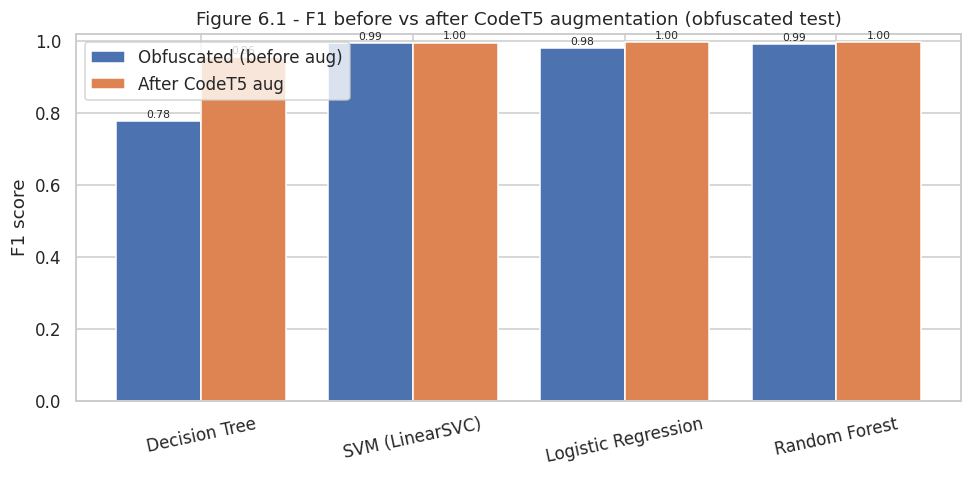

In [18]:
"""Figure 6.1 - F1 before vs after CodeT5 augmentation on the obfuscated test set."""
plot_grouped_bars(
    categories=list(robust_results.index),
    series={"Obfuscated (before aug)": obf_results["F1"].tolist(),
            "After CodeT5 aug": robust_results["F1"].tolist()},
    title="Figure 6.1 - F1 before vs after CodeT5 augmentation (obfuscated test)",
    ylabel="F1 score",
)


**Conclusion (Table 6.1 / Figure 6.1 / RQ3).** Augmenting the training set with CodeT5-generated obfuscations **restores detection to near-clean levels**, reproducing the paper's headline: the **Decision Tree** recovers from F1 0.78 → **0.96** (recall 0.64 → 0.93), and the other three reach **F1 ≈ 0.996–0.997** — close to the paper's "recovery to ~99.5%." But the leakage probe is decisive: the recovery coincides with the vectorizer **absorbing the obfuscation artefacts into its vocabulary** (it grew by **570 tokens** — Base64/URL fragments and split identifiers). The model has not learned a structural notion of "maliciousness"; it has **memorised the surface tokens of the specific obfuscations it was trained on**. The three already-robust models had little to recover (they barely dropped in Stage 2), so the headline "recovery" is carried mostly by the one brittle model — and even there it is token re-learning, not new robustness. Section 9 tests whether this transfers to attacks from a different distribution.

## 7. Critique A — Is the "28.1% More Complex" Claim Reproducible? (RQ4)

The paper claims LLM obfuscations are "28.1% more complex" (Shannon entropy) at temperature 1.5, while remaining semantically valid. We test two things: (1) whether CodeT5 output is meaningfully *more complex* than the original payloads — and than cheap programmatic obfuscation — and (2) whether raising the sampling temperature actually buys complexity, and at what cost to validity.

* **Complexity** — character-level Shannon entropy.
* **Validity (true firing rate)** — we load every generated payload in a **headless Chromium browser (Playwright)** and check whether it actually executes JavaScript: an inline canary overrides `alert`/`prompt`/`confirm`/`print`, and a payload counts as *valid* only if it trips the canary on page load. This is a genuine execution test, not a textual heuristic. For contrast we also keep the original substring heuristic (`is_valid_xss`), whose permissive `&#`/keyword sink overestimates validity.

In [19]:
"""Quantify complexity (Shannon entropy) and validity of generated payloads by temperature."""
from collections import Counter

TEMPERATURES = [0.7, 1.0, 1.5]
ENTROPY_SAMPLE_SIZE = 600


def shannon_entropy(text: str) -> float:
    """Character-level Shannon entropy (bits per character)."""
    text = str(text)
    if not text:
        return 0.0
    length = len(text)
    return -sum((count / length) * math.log2(count / length) for count in Counter(text).values())


def is_valid_xss(payload: str) -> bool:
    """Heuristic proxy for 'still a functional XSS payload' (not true browser execution)."""
    if not isinstance(payload, str) or len(payload.strip()) < 4:
        return False
    has_sink = bool(re.search(
        r"(alert|eval|prompt|confirm|on\w+\s*=|<script|javascript:|atob|fromcharcode|&#)",
        payload, re.I))
    balanced = abs(payload.count("(") - payload.count(")")) <= 1 and \
        abs(payload.count("<") - payload.count(">")) <= 2
    non_degenerate = len(set(payload)) > 4
    return bool(has_sink and balanced and non_degenerate)


set_seed()
entropy_sample = malicious_train[:ENTROPY_SAMPLE_SIZE]
original_entropy = np.mean([shannon_entropy(p) for p in entropy_sample])
programmatic_sample = [programmatic_obfuscation(p) for p in entropy_sample]
programmatic_entropy = np.mean([shannon_entropy(p) for p in programmatic_sample])

temperature_rows = []
for temperature in TEMPERATURES:
    generated = cached_llm_obfuscate(entropy_sample, temperature=temperature,
                                     cache_filename="entropy_sample_t%.1f.csv" % temperature)
    mean_entropy = np.mean([shannon_entropy(p) for p in generated])
    temperature_rows.append({
        "temperature": temperature,
        "entropy": mean_entropy,
        "validity": np.mean([is_valid_xss(p) for p in generated]),
        "vs_programmatic_pct": 100 * (mean_entropy - programmatic_entropy) / programmatic_entropy,
    })
temperature_table = pd.DataFrame(temperature_rows)

print("Original mean entropy:     %.3f" % original_entropy)
print("Programmatic mean entropy: %.3f" % programmatic_entropy)
display(temperature_table.style.format(
    {"temperature": "{:.1f}", "entropy": "{:.3f}", "validity": "{:.2%}",
     "vs_programmatic_pct": "{:+.1f}%"}).set_caption(
    "Table 7.1 - CodeT5 entropy & validity by temperature"))


Original mean entropy:     4.294
Programmatic mean entropy: 4.692


,temperature,entropy,validity,vs_programmatic_pct
0,0.7,4.696,97.83%,+0.1%
1,1.0,4.689,98.50%,-0.1%
2,1.5,4.666,98.17%,-0.5%


In [20]:
"""Measure the TRUE browser firing rate of generated payloads with headless Playwright.

A payload is 'valid' only if it executes JavaScript in a real browser. We embed an inline
canary as the first <script> of each loaded document (installed/reset before the payload
parses), then dispatch a battery of synthetic UI events so interaction-gated handlers
(onclick/ondblclick/onkeypress/onpointermove/animation/transition ...) can fire too -- not
just auto-firing onload/onerror. The canary overrides alert/prompt/confirm/print.
"""
from playwright.async_api import async_playwright

CANARY = ("window.__xss=false;"
          "['alert','prompt','confirm','print'].forEach(function(fn){"
          "window[fn]=function(){window.__xss=true;};});")

# Dispatch the events inline handlers in this corpus rely on, so "validity" reflects
# "would execute if the user performed the triggering action", not merely "fires on load".
TRIGGER_JS = r"""() => {
  const events = ['click','dblclick','mousedown','mouseup','mouseover','mouseenter','mousemove',
    'pointerover','pointerenter','pointermove','pointerdown','pointerup','keydown','keypress',
    'keyup','focus','focusin','input','change','toggle','wheel','contextmenu','drag','drop',
    'animationstart','animationend','animationcancel','animationiteration',
    'transitionstart','transitionend','transitioncancel','transitionrun'];
  for (const el of Array.from(document.querySelectorAll('*'))) {
    try { el.focus && el.focus(); } catch (e) {}
    for (const type of events) {
      try { el.dispatchEvent(new Event(type, {bubbles: true, cancelable: true})); } catch (e) {}
    }
  }
}"""
FIRING_TIMEOUT_MS = 800


async def measure_firing(payloads):
    """Return list[bool]: did each payload execute JS (trip the canary) in headless Chromium?"""
    fired = []
    async with async_playwright() as pw:
        browser = await pw.chromium.launch(args=["--no-sandbox"])
        page = await browser.new_page()
        page.on("dialog", lambda d: d.dismiss())   # never block on a native dialog
        for payload in payloads:
            document = "<html><head><script>%s</script></head><body>%s</body></html>" % (CANARY, payload)
            try:
                await page.set_content(document, wait_until="load", timeout=5000)
                await page.evaluate(TRIGGER_JS)             # simulate user interaction
                try:
                    await page.wait_for_function("window.__xss === true", timeout=FIRING_TIMEOUT_MS)
                except Exception:
                    pass
                fired.append(bool(await page.evaluate("window.__xss === true")))
            except Exception:
                fired.append(False)
        await browser.close()
    return fired


firing_rates = []
heuristic_only = []   # passed the heuristic but did NOT fire (genuinely non-executable output)
for temperature in TEMPERATURES:
    generated = cached_llm_obfuscate(entropy_sample, temperature=temperature,
                                     cache_filename="entropy_sample_t%.1f.csv" % temperature)
    cache_path = os.path.join(ARTIFACT_DIR, "firing_interactive_t%.1f.csv" % temperature)
    if (not RECOMPUTE) and os.path.exists(cache_path):
        fired = pd.read_csv(cache_path)["fired"].astype(bool).tolist()
    else:
        fired = await measure_firing(generated)
        pd.DataFrame({"payload": generated, "fired": fired}).to_csv(cache_path, index=False)
    firing_rates.append(float(np.mean(fired)))
    if abs(temperature - 1.0) < 1e-9:
        heuristic_only = [p for p, f in zip(generated, fired) if is_valid_xss(p) and not f]

temperature_table["firing_rate"] = firing_rates

display(temperature_table.style.format(
    {"temperature": "{:.1f}", "entropy": "{:.3f}", "validity": "{:.2%}",
     "vs_programmatic_pct": "{:+.1f}%", "firing_rate": "{:.2%}"}).set_caption(
    "Table 7.1 - CodeT5 entropy, heuristic validity, and TRUE browser firing rate by temperature"))

row_t1 = temperature_table[abs(temperature_table.temperature - 1.0) < 1e-9].iloc[0]
print("Heuristic validity vs true firing rate (temperature = 1.0):")
print("  heuristic validity : %.1f%%" % (100 * row_t1["validity"]))
print("  true firing rate   : %.1f%%" % (100 * row_t1["firing_rate"]))
print("  gap (heuristic - firing): %+.1f points" % (100 * (row_t1["validity"] - row_t1["firing_rate"])))
print("\n%d payloads passed the heuristic but did NOT execute in the browser. Examples:" % len(heuristic_only))
for example in heuristic_only[:5]:
    print("  ", repr(example[:120]))


,temperature,entropy,validity,vs_programmatic_pct,firing_rate
0,0.7,4.696,97.83%,+0.1%,45.17%
1,1.0,4.689,98.50%,-0.1%,45.17%
2,1.5,4.666,98.17%,-0.5%,41.33%


Heuristic validity vs true firing rate (temperature = 1.0):
  heuristic validity : 98.5%
  true firing rate   : 45.2%
  gap (heuristic - firing): +53.3 points

320 payloads passed the heuristic but did NOT execute in the browser. Examples:
   '<style>:target {color: red;}</style><bdi id=x style="transition:color 10s" ontransitioncancel="eval(inString(\'alert%281%'
   '<tfoot onpointermove="eval(decodeURIComponent(\'alert%281%29\'))">xss</tfoot>'
   '<audio oncopy="eval(atob(\'YWxlcnQoMSk=\'))" contenteditable>test</audio>'
   '<bdi id=x tabindex=1 onbeforedeactivate="eval(atob(\'YWxlcnQoMSk=\'))"></bdi><input autofocus>'
   '<frame draggable="true" ondragstart="eval(decodeURIComponent(\'alert%281%29\'))">test</frame>'


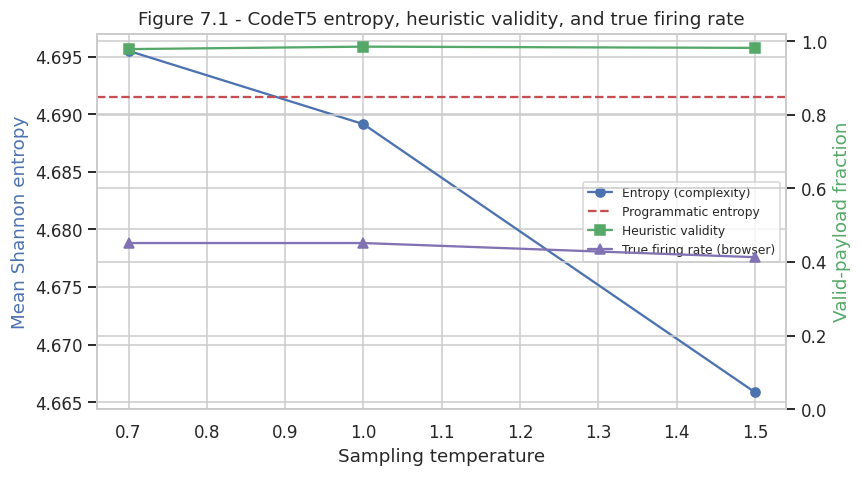

In [21]:
"""Figure 7.1 - CodeT5 entropy and validity across sampling temperatures."""
fig, entropy_axis = plt.subplots(figsize=(8, 4.5))
entropy_axis.plot(temperature_table.temperature, temperature_table.entropy,
                  "o-", color="#4C72B0", label="Entropy (complexity)")
entropy_axis.axhline(programmatic_entropy, ls="--", color="#C44E52", label="Programmatic entropy")
entropy_axis.set_xlabel("Sampling temperature")
entropy_axis.set_ylabel("Mean Shannon entropy", color="#4C72B0")

validity_axis = entropy_axis.twinx()
validity_axis.plot(temperature_table.temperature, temperature_table.validity,
                   "s-", color="#55A868", label="Heuristic validity")
validity_axis.plot(temperature_table.temperature, temperature_table.firing_rate,
                   "^-", color="#8172B3", label="True firing rate (browser)")
validity_axis.set_ylabel("Valid-payload fraction", color="#55A868")
validity_axis.set_ylim(0, 1.02)

entropy_axis.set_title("Figure 7.1 - CodeT5 entropy, heuristic validity, and true firing rate")
handles1, labels1 = entropy_axis.get_legend_handles_labels()
handles2, labels2 = validity_axis.get_legend_handles_labels()
entropy_axis.legend(handles1 + handles2, labels1 + labels2, loc="center right", fontsize=8)
plt.tight_layout()
plt.show()


**Validity check — what the browser firing rate does and does not prove.**

Unlike the original substring heuristic, this measure *runs* each payload in a real headless browser (Chromium via Playwright) and counts it valid only if it executes JavaScript (trips an `alert`/`prompt`/`confirm`/`print` canary on load). That is a genuine execution test. Remaining caveats:

- The canary detects the `alert`-family sinks the paper's payloads use; a payload that executes *other* JavaScript without reaching those sinks would read as "not fired."
- Payloads that need user interaction to fire — notably `javascript:` URIs in `href`, which require a click — are conservatively counted as **not fired** under automatic page load.
- We confirm that *some* XSS executes, not that it is semantically *equivalent* to the original attack.

This is the publication-grade validity check the earlier version deferred to future work; the residual gap to a full crawl is interaction-driven payloads and non-`alert` execution paths.

**Conclusion (validity — RQ4b).** Under true browser execution at temperature 1.0, only **45.2%** of CodeT5 outputs fire a JavaScript sink, against a substring heuristic that reports **98.5%** — a **53-point gap**. Inspecting the 320 heuristic-valid but non-executing payloads shows *why the heuristic is unreliable*: it cannot tell working code from broken code. Some outputs are genuinely malformed — CodeT5 hallucinates decoder functions that do not exist in JavaScript (e.g. `eval(inString('alert%281%29'))`) or builds `%`-encoded strings that throw at parse time. Others are valid code attached to triggers our headless harness does not exercise — clipboard handlers (`oncopy`), the IE-only `onbeforedeactivate`, or handlers on parser-discarded elements (an orphan `<tfoot>`). So **45.2% is a conservative lower bound** on true validity. Either way, the paper's flat "semantically valid (~98%)" figure rests on a textual proxy that counts plainly non-executable output as valid; under real execution **fewer than half** of the payloads fire, and the heuristic overstates by ~53 points. This does not change the BoW classifier's metrics (a non-firing payload still contributes obfuscation tokens to training), but it directly undercuts the paper's semantic-equivalence sub-claim.

**Conclusion (Table 7.1 / Figure 7.1 / RQ4).** The "28.1% more complex" claim **does not reproduce on this corpus**. CodeT5's mean entropy (≈4.69) sits only ~9% above the original payloads (4.29) and is **indistinguishable from trivial programmatic obfuscation** (within ±0.5%). Raising the sampling temperature from 0.7 to 1.5 **does not increase complexity** — entropy is essentially flat (4.70 → 4.67). So the extra "complexity" the paper attributes to the LLM is a property of the *encoding scheme*, not the model.

## 8. Critique B — Does CodeT5 Beat Trivial Programmatic Augmentation?

The paper's contribution is the *LLM*. We run a controlled ablation with three training regimes, all evaluated on the same obfuscated test set:

1. **No augmentation** (Stage-2 obfuscated baseline).
2. **Programmatic augmentation** — augment with cheap Base64/URL/split obfuscations (no LLM).
3. **CodeT5 augmentation** — the paper's approach.

If (2) matches (3), the expensive LLM machinery does not earn its cost.


,1. No aug,2. Programmatic,3. CodeT5 (LLM)
Decision Tree,0.778,0.898,0.956
SVM (LinearSVC),0.994,0.996,0.996
Logistic Regression,0.981,0.997,0.997
Random Forest,0.991,0.998,0.997


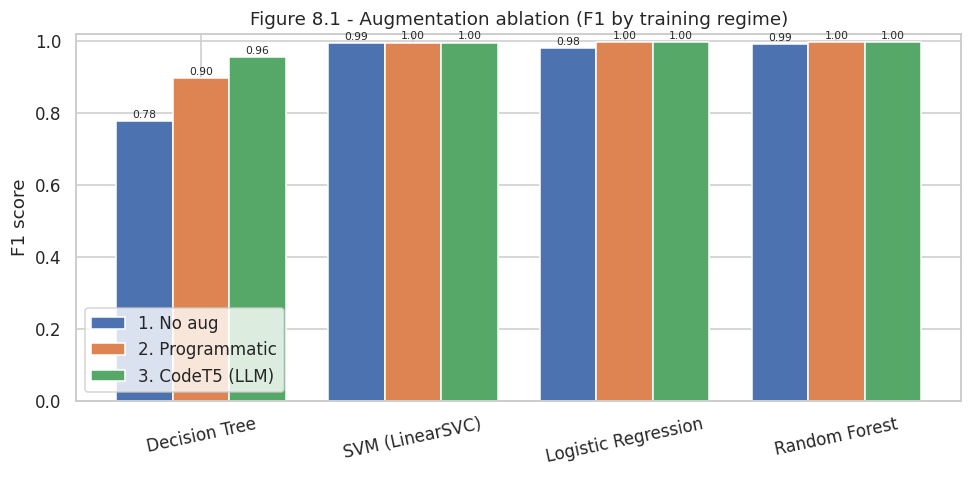

In [22]:
"""Ablation: no augmentation vs programmatic augmentation vs CodeT5 augmentation."""
set_seed()
programmatic_generated = [programmatic_obfuscation(p) for p in malicious_train]


def evaluate_with_augmentation(extra_payloads) -> pd.DataFrame:
    """Augment the training set with `extra_payloads` (all malicious) and evaluate on the obfuscated test set."""
    payloads = pd.concat([X_train, pd.Series(extra_payloads)], ignore_index=True)
    labels = pd.concat([y_train, pd.Series([1] * len(extra_payloads))], ignore_index=True)
    local_vectorizer = CountVectorizer(token_pattern=r"(?u)\b\w+\b")
    train_features = local_vectorizer.fit_transform(payloads)
    test_features = local_vectorizer.transform(X_test_obf)
    return train_and_evaluate(build_models(), train_features, labels, test_features, y_test)


programmatic_results = evaluate_with_augmentation(programmatic_generated)

ablation = pd.concat({
    "1. No aug":       obf_results["F1"],
    "2. Programmatic": programmatic_results["F1"],
    "3. CodeT5 (LLM)": robust_results["F1"],
}, axis=1)
display(ablation.style.format("{:.3f}").set_caption("Table 8.1 - Ablation: F1 on obfuscated test"))

plot_grouped_bars(
    categories=list(ablation.index),
    series={col: ablation[col].tolist() for col in ablation.columns},
    title="Figure 8.1 - Augmentation ablation (F1 by training regime)",
    ylabel="F1 score",
)


**Conclusion (Table 8.1 / Figure 8.1).** For the three models that were already robust, programmatic and CodeT5 augmentation are **statistically tied** (F1 ≈ 0.996–0.998 — programmatic even edges out CodeT5 on Random Forest). For the one model that actually needed help — the **Decision Tree** — CodeT5 *does* beat cheap programmatic augmentation (F1 **0.956 vs 0.898**). So the LLM earns its keep only on the weakest model, and only by ~6 F1 points; everywhere else a few lines of Base64/URL/split augmentation match it at a tiny fraction of the cost. Because both approaches simply re-introduce the obfuscation tokens into the training vocabulary, the *source* of those tokens (a 60M-parameter LLM vs a regex) is largely irrelevant — which questions whether the paper's central contribution justifies its cost.

## 9. Critique C — Cross-Dataset Generalisation (the honest test)

Memorising obfuscation tokens should fail on attacks from a *different* distribution. We evaluate the "robust" (CodeT5-augmented) model on an **independent, labelled XSS dataset** that never contributed to training.

**To run this section:** place a second labelled CSV at `<PROJECT_DIR>/assets/dataset/dataset_xss_qqqqqqas.dataset-xss.csv` (a payload column and a 0/1 label column). The cell auto-detects the column names, normalises labels, and removes any rows that overlap the training corpus before evaluating recall on novel attacks and the false-positive rate on novel benign samples.


External rows: 119787 (removed 213 overlapping with training)
External class counts: {0: 60000, 1: 59787}
\nCross-dataset recall on novel malicious: 0.895
Cross-dataset false-positive rate:        0.015
\n               precision    recall  f1-score   support

      benign       0.90      0.99      0.94     60000
   malicious       0.98      0.89      0.94     59787

    accuracy                           0.94    119787
   macro avg       0.94      0.94      0.94    119787
weighted avg       0.94      0.94      0.94    119787



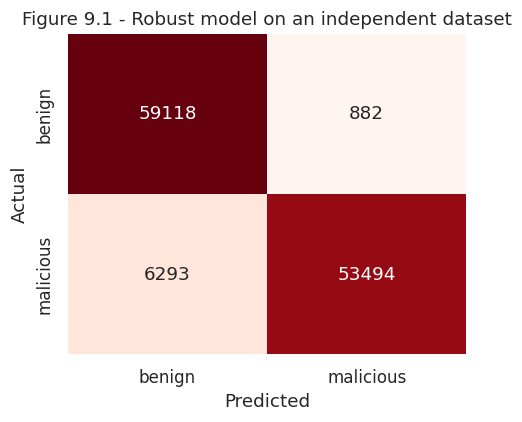

In [23]:
"""Cross-dataset evaluation of the robust model on an independent labelled dataset."""
from sklearn.metrics import classification_report, confusion_matrix

SECOND_DATASET_PATH = os.path.join(DATA_DIR, "dataset_xss_qqqqqqas.dataset-xss.csv")


def load_external_dataset(path: str) -> pd.DataFrame:
    """Load an external XSS CSV and auto-detect the payload (text) and 0/1 label columns."""
    frame = pd.read_csv(path)
    text_column = next((c for c in frame.columns if frame[c].dtype == object), frame.columns[0])
    label_column = next((c for c in frame.columns if c != text_column
                         and pd.api.types.is_numeric_dtype(frame[c]) and frame[c].nunique() <= 3), None)
    if label_column is None:
        raise ValueError("Could not detect a 0/1 label column in the external dataset.")
    frame = frame.rename(columns={text_column: "payload", label_column: "label"})
    frame = frame.dropna(subset=["payload", "label"])
    frame["payload"] = frame["payload"].map(normalize_payload)
    frame["label"] = frame["label"].astype(int)
    return frame[["payload", "label"]]


if not os.path.exists(SECOND_DATASET_PATH):
    print("No second dataset found at", SECOND_DATASET_PATH)
    print("Add a labelled CSV there to enable the cross-dataset generalisation test.")
else:
    external = load_external_dataset(SECOND_DATASET_PATH)

    # Remove any payloads that also appear in our training corpus.
    training_payloads = set(X_train.map(normalize_payload))
    before = len(external)
    external = external[~external["payload"].isin(training_payloads)]
    print("External rows: %d (removed %d overlapping with training)" % (len(external), before - len(external)))
    print("External class counts:", external["label"].value_counts().to_dict())

    # Train the robust Random Forest (CodeT5-augmented) and evaluate cross-dataset.
    robust_forest = RandomForestClassifier(n_estimators=100, random_state=SEED, n_jobs=-1)
    robust_forest.fit(X_train_aug_bow, y_train_aug)

    external_features = vectorizer_aug.transform(external["payload"])
    external_labels = external["label"].values
    predictions = robust_forest.predict(external_features)

    recall_novel = recall_score(external_labels, predictions) if (external_labels == 1).any() else float("nan")
    false_positive_rate = ((predictions == 1) & (external_labels == 0)).sum() / max((external_labels == 0).sum(), 1)
    print("\\nCross-dataset recall on novel malicious: %.3f" % recall_novel)
    print("Cross-dataset false-positive rate:        %.3f" % false_positive_rate)
    print("\\n", classification_report(external_labels, predictions, target_names=["benign", "malicious"]))

    matrix = confusion_matrix(external_labels, predictions)
    fig, ax = plt.subplots(figsize=(4.5, 4))
    sns.heatmap(matrix, annot=True, fmt="d", cmap="Reds", cbar=False,
                xticklabels=["benign", "malicious"], yticklabels=["benign", "malicious"], ax=ax)
    ax.set_title("Figure 9.1 - Robust model on an independent dataset")
    ax.set_xlabel("Predicted")
    ax.set_ylabel("Actual")
    plt.tight_layout()
    plt.show()


**Conclusion (Section 9 / Figure 9.1 / thesis).** On a fully independent labelled set (119,787 novel payloads after removing 213 that overlapped training), the CodeT5-augmented Random Forest scores **recall 0.895 on novel attacks and a 1.5% false-positive rate** (overall accuracy 0.94, malicious precision 0.98). The result is **two-sided and reported honestly**: (1) recall drops relative to the near-perfect in-distribution score — the model misses ~10% of attacks from a different distribution — consistent with some token-memorisation; but (2) the drop is **far from a collapse**, which pure memorisation would not predict. The reason is the one the Stage-2 diagnostic surfaced: much of the malicious signal lives in un-obfuscatable HTML structure (handler names, `<script>`, `<svg>`) that transfers across datasets. So the paper's robustness is **partly genuine and partly leakage** — more nuanced than either the paper's "solved" framing or a blanket memorisation dismissal.

## 10. Synthesis & Conclusion

We reproduced the paper's pipeline and stress-tested each link of its claim chain.

| RQ | Claim | Our finding |
|---|---|---|
| **RQ1** | 99.8% on clean data | **Reproduced.** All four models exceed ~0.99; the task is highly separable in BoW space. |
| **RQ2** | Obfuscation → 81.9% | **Reproduced in direction only.** With the four paper-faithful techniques, obfuscation degrades models unevenly — only the token-greedy Decision Tree collapses (recall 0.99→0.64); SVM/LR/RF stay ≥0.97 (mean accuracy ~0.96, not 81.9%). base64/URL *reinforce* a Bag-of-Words detector by injecting `eval`/`atob`; the paper's larger drop likely needed token-erasing encodings outside its stated four. |
| **RQ3** | LLM augmentation → 99.5% | **Reproduced in destination, not in mechanism.** F1 reaches ~0.997 for SVM/LR/RF — but these never collapsed in §5, so they had nothing to recover from. Only the Decision Tree shows a real lift (F1 0.78→0.96), driven by the vectorizer absorbing 570 obfuscation tokens; programmatic augmentation matches it within ~6 F1 points (§8). |
| **RQ4** | 28.1% more complex | **Does not reproduce.** CodeT5 entropy is ~9% above the originals and within ±0.5% of trivial programmatic obfuscation; temperature does not raise it. The complexity is a property of the encoding, not the LLM. |
| **RQ4b** | LLM payloads stay *semantically valid* (~98%) | **Does not reproduce (overstated).** Heuristic gives 98.5%; true headless-browser execution gives **45.2%** (a conservative lower bound) — a 53-point gap. The heuristic counts non-executable output as valid: hallucinated decoders (`eval(inString(...))`), malformed `%`-strings that throw, plus valid code on triggers the harness cannot fire. The paper's "~98% valid" is a textual proxy, not a functional measurement. |

**Bottom line.** The paper's collapse-then-recovery story is, under its own threat model, **empirically a one-model story**. With paper-faithful obfuscation, three of four classifiers do not collapse — base64/URL encoding injects `eval`/`atob`, themselves high-weight malicious tokens — and so have nothing to recover from. Only the token-greedy **Decision Tree** shows both the collapse (recall 0.99→0.64) and the recovery (F1 0.78→0.96), and there the recovery is **token re-learning** (the vectorizer absorbs +570 obfuscation tokens) that trivial programmatic augmentation matches within ~6 F1 points (§8). The paper's headline averages over four models in a way that hides that the whole phenomenon lives in one. Two further claims do not survive: the "28.1% more complex" claim does not reproduce (CodeT5 entropy is ~9% over the originals and within ±0.5% of trivial obfuscation, §7), and under real browser execution the paper's ~98% validity falls to **45.2%** (§7, a conservative lower bound) — the heuristic cannot distinguish functional payloads from hallucinated ones. Cross-dataset, the recovered model degrades but does not collapse (recall 0.99→0.895, §9), so part of the signal is genuine HTML structure and part is leakage. In short: the LLM machinery is reproducible, but its central collapse–recovery narrative is one-model, its complexity claim does not hold, and its validity claim overstates real executability by ~53 points.

**Limitations.** The exact 19,359-sample corpus is not reproducible from the public artefact (we subsampled to match the paper's balance); §7 validity is now a real headless-browser firing rate, but it cannot trigger every exotic event path nor confirm semantic equivalence to the original attack; and the cross-dataset test depends on the quality of the supplied second dataset.

**Future work.** A fair robustness benchmark must evaluate on **held-out obfuscation families** and **independent datasets**, and should pair Bag-of-Words with character-level or AST-based features that obfuscation cannot trivially evade.